# Adaptive Timeline Prediction — Data Processing & EDA
### Smart Crop Advisory System using Data Analytics

**Purpose of this notebook:**
This notebook covers the data processing and exploratory data analysis (EDA) for the
**feedback-driven adaptive timeline module** of the project. Unlike the crop
recommendation dataset (Kaggle, clean/balanced), this dataset is **synthetically
generated to resemble real-world messy data** — it contains missing values, outliers,
inconsistent category labels, mixed data types, and duplicate rows. This is intentional:
it lets us demonstrate genuine data cleaning and preprocessing work rather than using an
already-clean dataset.

**What this dataset represents:**
Each row simulates one instance where a farmer's soil/environment reading (`prev_*`
columns) was adjusted (`tweaked_*` columns) after the farmer submitted free-text
feedback (e.g. *"heavy rain expected tomorrow"*), which an LLM-based extraction module
parsed into `affected_feature`, `adjustment_direction`, and `adjustment_magnitude`.
The target variables are:
- `updated_crop_recommendation` — whether the recommended crop should change
- `timeline_shift_days` — how many days the farming timeline (sowing/fertilizing/harvest) should shift

**Notebook sections:**
1. Setup & Data Loading
2. Initial Inspection
3. Duplicate Removal
4. Categorical Text Normalization
5. Fixing Mixed-Type Columns
6. Missing Value Treatment
7. Outlier Detection & Treatment
8. Encoding Categorical Variables
9. Feature Scaling
10. Final Consistency Check
11. Exploratory Data Analysis (Visualizations)


## 1. Setup & Data Loading
Import the libraries needed for cleaning, encoding, scaling, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer

# Plot styling for cleaner, presentation-ready charts
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load the raw synthetic dataset
df = pd.read_csv("timeline_feedback_dataset.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1525, 25)


,record_id,prev_N,prev_P,prev_K,prev_pH,prev_temperature,prev_humidity,prev_rainfall,prev_crop_recommended,days_since_sowing,...,tweaked_P,tweaked_K,tweaked_pH,tweaked_temperature,tweaked_humidity,tweaked_rainfall,prev_harvest_success,region_id,updated_crop_recommendation,timeline_shift_days
0,1,50.39,95.93,28.14,12.78,17.73,73.08,159.07,blackgram,43,...,95.93,28.14,12.78,17.73,73.08,159.07,Success,R4,blackgram,2.3
1,2,84.34,54.54,64.02,8.53,28.50,53.18,212.11,blackgram,8,...,54.54,64.02,8.53,28.50,53.18,212.11,yes,R6,blackgram,-2.4
2,3,95.48,11.71,40.76,4.11,21.84,57.64,233.09,wheat,121,...,11.71,40.76,4.11,21.84,57.64,233.09,success,R1,wheat,1.2
3,4,57.11,70.34,34.69,5.98,21.76,50.96,169.99,chickpea,32,...,70.34,34.69,5.98,21.76,50.96,170.13,partial,R5,chickpea,-0.8
4,5,90.04,56.01,5.92,7.37,26.30,70.30,182.42,lentil,86,...,56.01,5.92,7.37,26.30,70.30,182.42,NaN,R6,lentil,5.8


## 2. Initial Inspection
Before touching the data, we profile it: data types, summary statistics, and how much
is missing per column. This is the standard first step in any data science pipeline —
it tells us exactly what cleaning work is needed later.

In [2]:
# Structural overview: column dtypes, non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   record_id                    1525 non-null   int64  
 1   prev_N                       1497 non-null   float64
 2   prev_P                       1498 non-null   float64
 3   prev_K                       1525 non-null   float64
 4   prev_pH                      1525 non-null   float64
 5   prev_temperature             1525 non-null   float64
 6   prev_humidity                1471 non-null   float64
 7   prev_rainfall                1525 non-null   float64
 8   prev_crop_recommended        1525 non-null   str    
 9   days_since_sowing            1525 non-null   int64  
 10  feedback_text_raw            1525 non-null   str    
 11  affected_feature             1437 non-null   str    
 12  adjustment_direction         1214 non-null   str    
 13  adjustment_magnitude         

In [3]:
# Statistical summary of numeric columns — useful for spotting impossible values
# (e.g. negative nitrogen, pH > 10) before we even plot anything
df.describe()


,record_id,prev_N,prev_P,prev_K,prev_pH,prev_temperature,prev_humidity,prev_rainfall,days_since_sowing,tweaked_N,tweaked_P,tweaked_K,tweaked_pH,tweaked_temperature,tweaked_humidity,tweaked_rainfall,timeline_shift_days
count,1525.000000,1497.000000,1498.000000,1525.000000,1525.000000,1525.000000,1471.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525.00000,1525.000000,1525.000000,1525.000000
mean,763.000000,67.540688,50.081842,48.016734,6.657121,25.987056,64.797961,161.413351,75.883934,67.684341,50.120164,48.016734,6.657121,26.03619,64.591049,161.913266,-0.082951
std,440.373894,24.117914,15.440822,17.865054,1.161218,5.041696,14.972602,116.295423,43.103188,24.221429,15.424817,17.865054,1.161218,5.70640,16.141942,119.577052,3.081234
min,1.000000,-19.720000,-2.070000,-21.060000,4.110000,8.870000,4.710000,-40.480000,1.000000,-19.720000,-2.070000,-21.060000,4.110000,7.39000,4.710000,-40.480000,-10.300000
25%,382.000000,55.230000,39.730000,36.250000,6.020000,22.620000,54.755000,108.790000,39.000000,55.070000,39.710000,36.250000,6.020000,22.47000,53.790000,105.540000,-2.100000
50%,763.000000,69.350000,50.020000,48.330000,6.570000,26.080000,64.540000,150.260000,75.000000,69.430000,50.100000,48.330000,6.570000,26.09000,64.370000,150.060000,-0.100000
75%,1144.000000,82.510000,60.947500,60.410000,7.100000,29.500000,75.280000,195.490000,115.000000,82.710000,60.990000,60.410000,7.100000,29.73000,75.300000,198.030000,2.000000
max,1525.000000,125.640000,97.510000,105.370000,13.940000,41.710000,105.110000,1173.110000,149.000000,141.060000,97.510000,105.370000,13.940000,52.16000,163.970000,1351.320000,10.600000


In [4]:
# Missing value count per column
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_%": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)


,missing_count,missing_%
adjustment_direction,311,20.39
adjustment_magnitude,242,15.87
region_id,196,12.85
prev_harvest_success,183,12.00
affected_feature,88,5.77
prev_humidity,54,3.54
prev_N,28,1.84
prev_P,27,1.77


## 3. Duplicate Removal
Duplicate rows can happen from repeated feedback submissions or logging retries in a
real system. We detect and remove exact duplicates so they don't bias the model
(e.g. by over-representing certain feature combinations).

In [5]:
rows_before = len(df)
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)
print(f"Rows before: {rows_before} -> Rows after removing duplicates: {rows_after}")


Duplicate rows found: 0
Rows before: 1525 -> Rows after removing duplicates: 1525


## 4. Categorical Text Normalization
Free-text-derived categorical columns (`affected_feature`, `adjustment_direction`,
`region_id`, `prev_harvest_success`, `prev_crop_recommended`) contain inconsistent
casing and spacing (e.g. `"Rainfall"`, `"RAINFALL"`, `" rainfall"`, `"rain"` should all
mean the same thing). We normalize these to a single canonical form — this step alone
often fixes what looks like "many rare categories" into a small, meaningful set.

In [6]:
def normalize_text(x):
    if pd.isna(x):
        return x
    return str(x).strip().lower()

for col in ["affected_feature", "adjustment_direction", "region_id",
            "prev_harvest_success", "prev_crop_recommended", "updated_crop_recommendation"]:
    df[col] = df[col].apply(normalize_text)

# Map known synonyms/abbreviations to one canonical label
feature_map = {
    "rain": "rainfall", "rainfall": "rainfall",
    "temp": "temperature", "temperature": "temperature",
    "humid": "humidity", "humidity": "humidity",
    "soilmoisture": "soil_moisture", "soil moisture": "soil_moisture", "soil_moisture": "soil_moisture",
}
df["affected_feature"] = df["affected_feature"].replace(feature_map)

harvest_map = {"yes": "success", "no": "failure", "success": "success",
               "failure": "failure", "partial": "partial"}
df["prev_harvest_success"] = df["prev_harvest_success"].replace(harvest_map)

# region_id: strip leading zero-casing issues like 'r1' vs 'R1'
df["region_id"] = df["region_id"].str.upper()

print("Unique affected_feature values after cleaning:", df["affected_feature"].unique())
print("Unique prev_harvest_success values after cleaning:", df["prev_harvest_success"].unique())
print("Unique region_id values after cleaning:", df["region_id"].unique())


Unique affected_feature values after cleaning: <StringArray>
[nan, 'temperature', 'soil_moisture', 'rainfall', 'humidity']
Length: 5, dtype: str
Unique prev_harvest_success values after cleaning: <StringArray>
['success', 'partial', nan, 'failure']
Length: 4, dtype: str
Unique region_id values after cleaning: <StringArray>
['R4', 'R6', 'R1', 'R5', nan, 'R2', 'R3']
Length: 7, dtype: str


## 5. Fixing Mixed-Type Columns
`adjustment_magnitude` was stored inconsistently — some values as percentage strings
(e.g. `"30%"`) and others as raw numeric fractions (e.g. `0.3`). We convert everything
to one consistent numeric scale (fraction, 0–1) so it can be used in modeling.

In [7]:
def clean_magnitude(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x.endswith("%"):
        return float(x.replace("%", "")) / 100
    try:
        val = float(x)
        # if it looks like it was already meant as a percentage (e.g. 30 instead of 0.30)
        return val / 100 if val > 1 else val
    except ValueError:
        return np.nan

df["adjustment_magnitude"] = df["adjustment_magnitude"].apply(clean_magnitude)
df["adjustment_magnitude"].describe()


count    1283.000000
mean        0.327989
std         0.160636
min         0.050000
25%         0.195000
50%         0.330000
75%         0.470000
max         0.600000
Name: adjustment_magnitude, dtype: float64

## 6. Missing Value Treatment
Different columns need different imputation strategies:

- **Numeric soil/environment readings** (`prev_N`, `prev_P`, `prev_humidity`): imputed
  using **KNN Imputation**, which estimates missing values based on similar rows rather
  than a flat mean/median — more appropriate given the multivariate relationships in
  this data.
- **Categorical feedback fields** (`affected_feature`, `adjustment_direction`,
  `adjustment_magnitude`, `region_id`, `prev_harvest_success`): filled with an explicit
  `"unknown"` category (or 0 for magnitude) rather than the mode, because a *missing*
  feedback is meaningfully different from a *guessed* one — imputing with the mode would
  falsely imply the farmer gave feedback when they didn't.

In [8]:
# --- Numeric imputation (KNN-based) ---
numeric_impute_cols = ["prev_N", "prev_P", "prev_humidity"]
imputer = KNNImputer(n_neighbors=5)
df[numeric_impute_cols] = imputer.fit_transform(df[numeric_impute_cols])

# --- Categorical / feedback-related imputation ---
df["affected_feature"] = df["affected_feature"].fillna("unknown")
df["adjustment_direction"] = df["adjustment_direction"].fillna("unknown")
df["adjustment_magnitude"] = df["adjustment_magnitude"].fillna(0)
df["region_id"] = df["region_id"].fillna("UNKNOWN")
df["prev_harvest_success"] = df["prev_harvest_success"].fillna("unknown")

print("Remaining missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])


Remaining missing values:
 Series([], dtype: int64)


## 7. Outlier Detection & Treatment
We use the **IQR (Interquartile Range) method** to flag values that fall far outside
the normal range — these represent simulated sensor errors (e.g. negative nitrogen,
impossible soil pH, extreme rainfall spikes). We visualize before/after with boxplots,
then clip values to realistic domain-informed bounds rather than dropping rows
(dropping would lose otherwise-valid data in other columns).

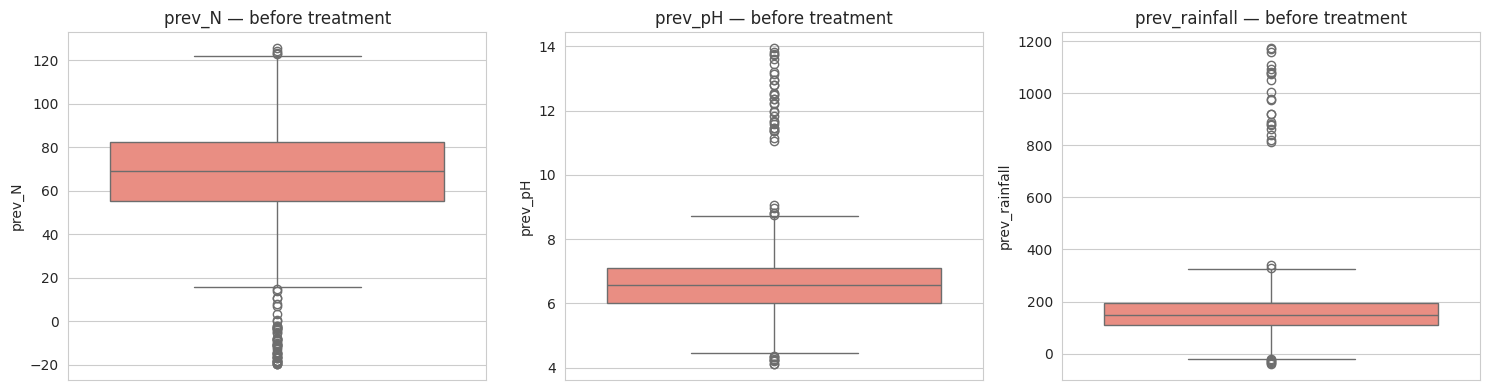

In [9]:
outlier_cols = ["prev_N", "prev_pH", "prev_rainfall"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="salmon")
    ax.set_title(f"{col} — before treatment")
plt.tight_layout()
plt.show()


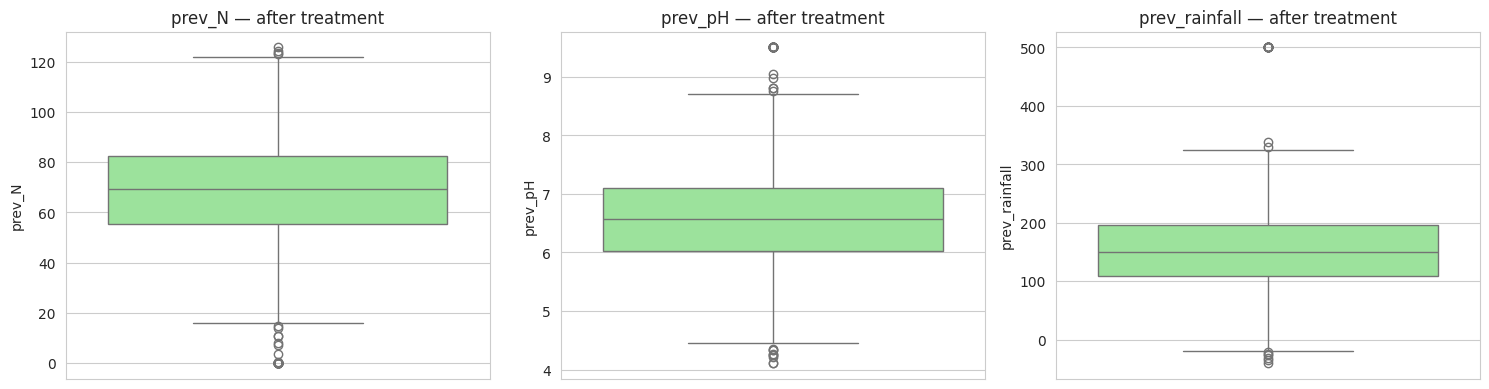

In [10]:
# Domain-informed realistic bounds (not just statistical IQR, since soil science
# gives us known valid ranges):
# - Nitrogen (N): should not be negative
# - Soil pH: realistically ranges ~3.5 to 9.5
# - Rainfall: realistic daily/seasonal aggregate capped at 500mm for this dataset's context

df["prev_N"] = df["prev_N"].clip(lower=0)
df["prev_pH"] = df["prev_pH"].clip(lower=3.5, upper=9.5)
df["prev_rainfall"] = df["prev_rainfall"].clip(upper=500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightgreen")
    ax.set_title(f"{col} — after treatment")
plt.tight_layout()
plt.show()


## 8. Encoding Categorical Variables
Since our models (Random Forest classifier/regressor) will be tree-based, **Label
Encoding** is sufficient and avoids the dimensionality blow-up of one-hot encoding on
higher-cardinality columns like `prev_crop_recommended` (16 crop classes).

In [11]:
categorical_cols = ["affected_feature", "adjustment_direction", "region_id",
                    "prev_harvest_success", "prev_crop_recommended", "updated_crop_recommendation"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + "_encoded"] = le.fit_transform(df[col])
    encoders[col] = le  # keep encoders in case we need to inverse_transform later

df[[c for c in df.columns if c.endswith("_encoded")]].head()


,affected_feature_encoded,adjustment_direction_encoded,region_id_encoded,prev_harvest_success_encoded,prev_crop_recommended_encoded,updated_crop_recommendation_encoded
0,4,1,3,2,1,1
1,3,1,5,2,1,1
2,2,2,0,2,15,15
3,1,1,4,1,2,2
4,2,2,5,3,8,8


## 9. Feature Scaling
We scale numeric features using **StandardScaler** so that features with larger raw
ranges (e.g. `prev_rainfall` ~0–500) don't dominate features with smaller ranges
(e.g. `prev_pH` ~3.5–9.5) during model training.

In [12]:
numeric_cols = ["prev_N","prev_P","prev_K","prev_pH","prev_temperature","prev_humidity",
                "prev_rainfall","tweaked_N","tweaked_P","tweaked_K","tweaked_pH",
                "tweaked_temperature","tweaked_humidity","tweaked_rainfall",
                "days_since_sowing","adjustment_magnitude"]

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df[numeric_cols])
df_scaled = pd.DataFrame(scaled_array, columns=[c + "_scaled" for c in numeric_cols])

df_final = pd.concat([df.reset_index(drop=True), df_scaled], axis=1)
df_final.head()


,record_id,prev_N,prev_P,prev_K,prev_pH,prev_temperature,prev_humidity,prev_rainfall,prev_crop_recommended,days_since_sowing,...,prev_rainfall_scaled,tweaked_N_scaled,tweaked_P_scaled,tweaked_K_scaled,tweaked_pH_scaled,tweaked_temperature_scaled,tweaked_humidity_scaled,tweaked_rainfall_scaled,days_since_sowing_scaled,adjustment_magnitude_scaled
0,1,50.39,95.93,28.14,9.50,17.73,73.08,159.07,blackgram,43,...,0.059608,-0.714244,2.970853,-1.112969,5.274538,-1.456069,0.526067,-0.023785,-0.763162,-0.083953
1,2,84.34,54.54,64.02,8.53,28.50,53.18,212.11,blackgram,8,...,0.779632,0.687867,0.286635,0.896080,1.613387,0.431904,-0.707151,0.419923,-1.575433,-1.453239
2,3,95.48,11.71,40.76,4.11,21.84,57.64,233.09,wheat,121,...,1.064438,1.147941,-2.490971,-0.406330,-2.194211,-0.735589,-0.430762,0.595433,1.047042,0.390031
3,4,57.11,70.34,34.69,5.98,21.76,50.96,169.99,chickpea,32,...,0.207848,-0.436713,1.311294,-0.746211,-0.583304,-0.749613,-0.844726,0.068738,-1.018447,-1.031920
4,5,90.04,56.01,5.92,7.37,26.30,70.30,182.42,lentil,86,...,0.376587,0.923273,0.381967,-2.357146,0.614108,0.046246,0.353788,0.171550,0.234771,1.074674


## 10. Final Consistency Check
A final sanity check confirms the cleaning pipeline worked: no duplicates, no
unexpected missing values, and a summary of how much the dataset changed from raw to
cleaned. This before/after comparison is worth including directly in your report.

In [13]:
print("Final shape:", df_final.shape)
print("Remaining duplicates:", df_final.duplicated().sum())
print("Remaining missing values:", df_final.isnull().sum().sum())

comparison = pd.DataFrame({
    "Metric": ["Rows", "Duplicate rows", "Total missing values"],
    "Before Cleaning": [rows_before, duplicate_count, int(missing_summary['missing_count'].sum())],
    "After Cleaning": [df_final.shape[0], df_final.duplicated().sum(), df_final.isnull().sum().sum()]
})
comparison


Final shape: (1525, 47)
Remaining duplicates: 0
Remaining missing values: 0


,Metric,Before Cleaning,After Cleaning
0,Rows,1525,1525
1,Duplicate rows,0,0
2,Total missing values,1129,0


In [14]:
# Save the cleaned dataset for use in model training notebooks
df_final.to_csv("timeline_feedback_dataset_cleaned.csv", index=False)
print("Cleaned dataset saved.")


Cleaned dataset saved.


## 11. Exploratory Data Analysis (Visualizations)
This section produces the key charts for the "Data Analysis" part of the project demo —
each one tells a specific story about the data or supports the adaptive-timeline
hypothesis.

### 11.1 Missingness Heatmap (on original raw data)
Shows exactly where missing values occurred before cleaning — a strong visual for demonstrating the dataset wasn't artificially clean.

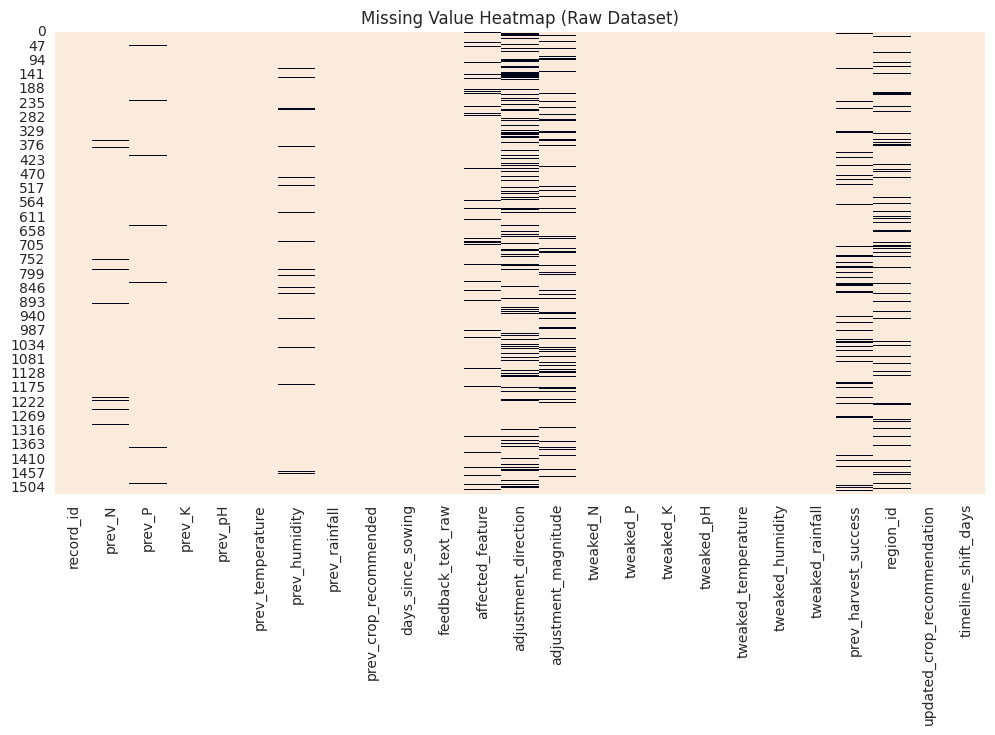

In [15]:
df_raw = pd.read_csv("timeline_feedback_dataset.csv")
plt.figure(figsize=(12, 6))
sns.heatmap(df_raw.isnull(), cbar=False, cmap="rocket_r")
plt.title("Missing Value Heatmap (Raw Dataset)")
plt.show()


### 11.2 Correlation Heatmap
Shows which numeric features are most related to `timeline_shift_days` — supports feature selection and justifies model design.

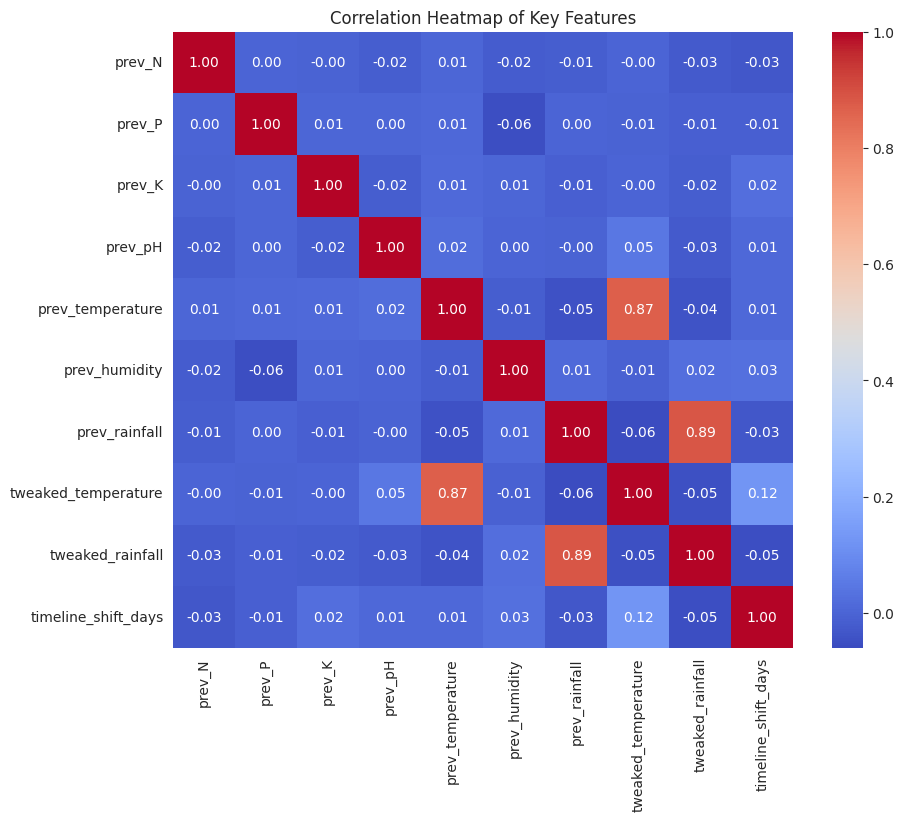

In [16]:
corr_cols = ["prev_N","prev_P","prev_K","prev_pH","prev_temperature","prev_humidity",
             "prev_rainfall","tweaked_temperature","tweaked_rainfall","timeline_shift_days"]
plt.figure(figsize=(10, 8))
sns.heatmap(df_final[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Features")
plt.show()


### 11.3 Distribution of Target Variable (`timeline_shift_days`)
Understanding the target's spread justifies using a regression model and shows whether it's roughly normal or skewed.

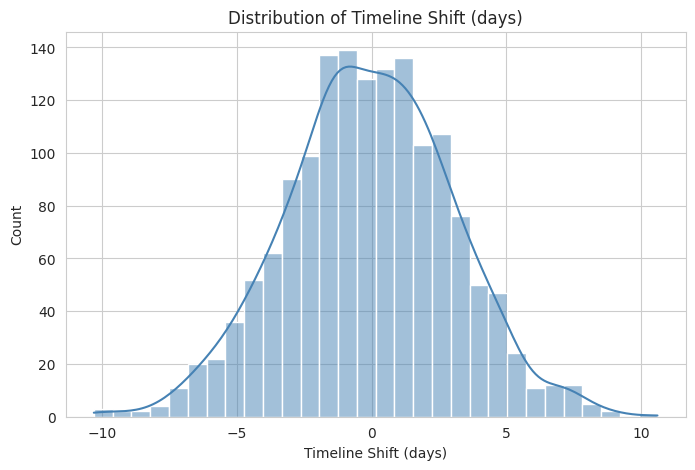

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df_final["timeline_shift_days"], kde=True, color="steelblue")
plt.title("Distribution of Timeline Shift (days)")
plt.xlabel("Timeline Shift (days)")
plt.show()


### 11.4 Frequency of Affected Feature (Feedback Type)
Shows which type of farmer feedback (rainfall/temperature/humidity/soil moisture) is most common after normalization.

/tmp/ipykernel_505/2336884031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="affected_feature", order=order, palette="viridis")


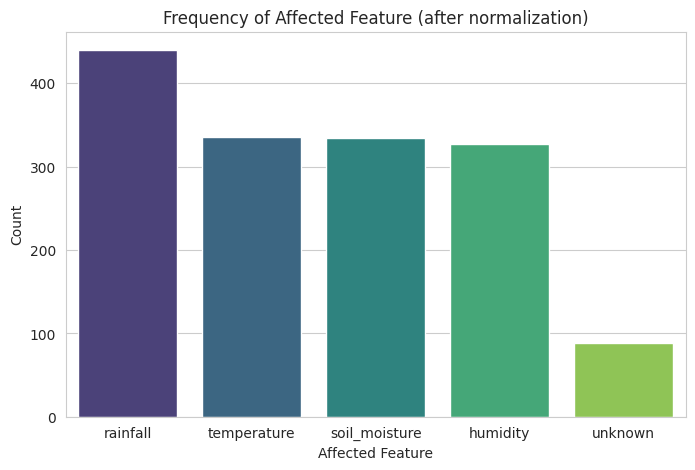

In [18]:
plt.figure(figsize=(8,5))
order = df_final["affected_feature"].value_counts().index
sns.countplot(data=df_final, x="affected_feature", order=order, palette="viridis")
plt.title("Frequency of Affected Feature (after normalization)")
plt.xlabel("Affected Feature")
plt.ylabel("Count")
plt.show()


### 11.5 Rainfall Delta vs Timeline Shift
Directly visualizes the core hypothesis of the adaptive module: a change in rainfall (from farmer feedback) should correlate with a shift in the recommended timeline.

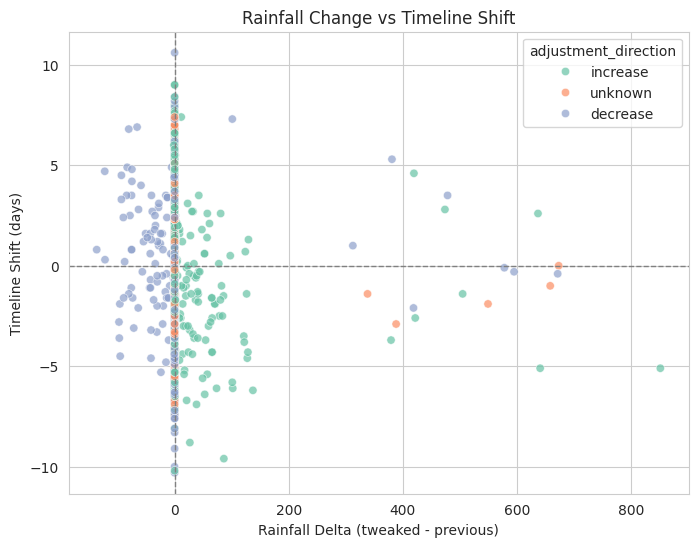

In [19]:
df_final["rainfall_delta"] = df_final["tweaked_rainfall"] - df_final["prev_rainfall"]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_final, x="rainfall_delta", y="timeline_shift_days",
                 hue="adjustment_direction", palette="Set2", alpha=0.7)
plt.title("Rainfall Change vs Timeline Shift")
plt.xlabel("Rainfall Delta (tweaked - previous)")
plt.ylabel("Timeline Shift (days)")
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.axvline(0, color="grey", linestyle="--", linewidth=1)
plt.show()


### 11.6 Boxplot: Timeline Shift by Previous Harvest Outcome
Explores whether past harvest success/failure relates to the magnitude of timeline adjustments — a link to the outcome-feedback loop discussed earlier in the project.

/tmp/ipykernel_505/1187874155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="prev_harvest_success", y="timeline_shift_days", palette="pastel")


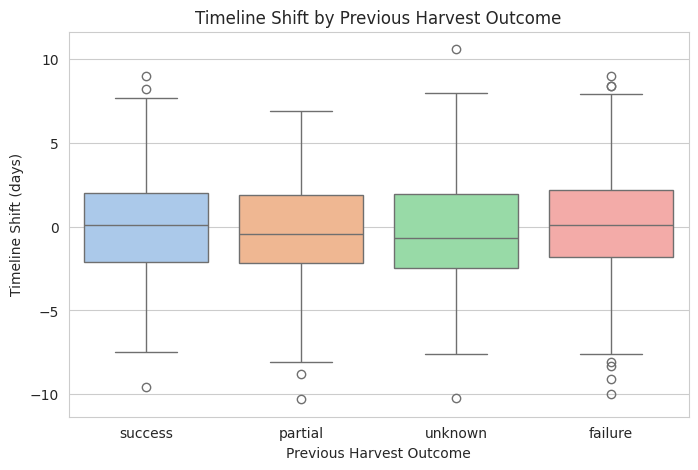

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_final, x="prev_harvest_success", y="timeline_shift_days", palette="pastel")
plt.title("Timeline Shift by Previous Harvest Outcome")
plt.xlabel("Previous Harvest Outcome")
plt.ylabel("Timeline Shift (days)")
plt.show()
